In [1]:
import requests
from bs4 import BeautifulSoup
import csv
import logging
import os
from datetime import datetime
import pandas as pd
import requests
from bs4 import BeautifulSoup
from datetime import datetime

In [2]:
log_directory = "logs"
if not os.path.exists(log_directory):
    os.makedirs(log_directory, exist_ok = True)

In [3]:
naco_achievement_database = pd.read_csv("naco_achievement_database.csv")
print(naco_achievement_database.shape)

(8730, 6)


In [4]:
naco_achievement_database.head()

,year,county,program,program_link,category,best_in_category
0,2023,"Citrus County, Fla.","Scripting for Security, Standardization, and S...",https://www.naco.org/resources/award-programs/...,Information Technology,False
1,2023,"Montgomery County, Md.",Kids Day Out,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False
2,2023,"Montgomery County, Md.",Let Her Shine – Girls Volleyball,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False
3,2023,"Montgomery County, Md.",Inclusion Multi-Sport Program,https://www.naco.org/resources/award-programs/...,Parks and Recreation,False
4,2023,"Montgomery County, Md.",Case Portal for Subpoena Management,https://www.naco.org/resources/award-programs/...,NaN,False


* to do: separate county from state, make a state column
* create distributions by state/time

In [5]:
naco_achievement_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8730 entries, 0 to 8729
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   year              8730 non-null   int64 
 1   county            8729 non-null   object
 2   program           8730 non-null   object
 3   program_link      8730 non-null   object
 4   category          8729 non-null   object
 5   best_in_category  8730 non-null   bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 349.7+ KB


In [6]:
naco_achievement_database["county"].value_counts()

county
San Bernardino County, Calif.                   678
Los Angeles County, Calif.                      649
San Diego County, Calif.                        634
Maricopa County, Ariz.                          565
Miami-Dade County, Fla.                         513
                                               ... 
Association of County Commissions of Alabama      1
Saratoga County, N.Y.                             1
DeKalb County, Ill.                               1
Hinsdale County, Colo.                            1
Colusa County, Calif.                             1
Name: count, Length: 448, dtype: int64

In [7]:
naco_achievement_database["category"].value_counts()

category
Information Technology                           1288
Human Services                                    777
Criminal Justice and Public Safety                760
Health                                            712
Civic Education and Public Information            618
Personnel Management, Employment and Training     590
County Administration and Management              553
Children and Youth                                539
Community and Economic Development                507
Libraries                                         503
County Resiliency                                 497
Parks and Recreation                              335
Risk and Emergency Management                     335
Transportation                                    175
Arts, Culture and Historic Preservation           168
Financial Management                              147
Planning                                          134
Volunteers                                         91
Name: count, dtype:

In [8]:
naco_achievement_database["best_in_category"].value_counts()

best_in_category
False    8217
True      513
Name: count, dtype: int64

In [9]:
pd.crosstab(naco_achievement_database.category,
            naco_achievement_database.best_in_category, normalize='index')

best_in_category,False,True
category,,
"Arts, Culture and Historic Preservation",0.892857,0.107143
Children and Youth,0.949907,0.050093
Civic Education and Public Information,0.944984,0.055016
Community and Economic Development,0.942801,0.057199
County Administration and Management,0.933092,0.066908
County Resiliency,0.937626,0.062374
Criminal Justice and Public Safety,0.938158,0.061842
Financial Management,0.891156,0.108844
Health,0.955056,0.044944


In [10]:
pd.crosstab(naco_achievement_database.county,
            naco_achievement_database.best_in_category, normalize='index')

best_in_category,False,True
county,,
ACCG – Advancing Georgia's Counties,1.000000,0.000000
"Adams County, Colo.",0.777778,0.222222
"Alachua County, Fla.",0.875000,0.125000
"Alameda County, Calif.",0.961538,0.038462
Alaska Municipal League,0.000000,1.000000
...,...,...
"Yankton County, S.D.",1.000000,0.000000
"Yavapai County, Ariz.",1.000000,0.000000
"York County, Va.",0.951220,0.048780


<AxesSubplot:>

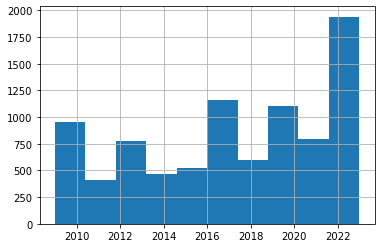

In [11]:
naco_achievement_database["year"].hist()

In [12]:
def scrape_award_info(text):
    year = ""
    category = ""
    description = ""
    best_in_category = False

    # Extract category
    category_start_index = text.find("Category:") + len("Category:")
    category_end_index = text.find("Year:")
    category = text[category_start_index:category_end_index].strip()
    if "(Best in Category)" in category:
        best_in_category = True
        category = category.replace("(Best in Category)", "").strip()

    # Extract year
    year_start_index = text.find("Year:") + len("Year:")
    year_end_index = [i for i in range(len(text)) if text.startswith('\n', i)][-1]
    year = text[year_start_index:year_end_index].strip()

    # Extract text below the year
    description = text[year_end_index:].strip()
    description = description.replace("â€œ", "'")
    description = description.replace("â€", "'")
    description = description.replace("\x9d", "")
    return {
        "program": "",
        "county": "",
        "year": year,
        "category": category,
        "description": description,
        "best_in_category": best_in_category
    }

In [13]:
def scrape_award_page(url):
    try:
        # Send a GET request to the URL
        response = requests.get(url)

        # Check if the request was successful
        if response.status_code != 200:
            print(f"Failed to retrieve the page. Status code: {response.status_code}")
            return {}

        # Parse the HTML content using BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Initialize the dictionary to store the extracted data
        award_data = {
            "program": "",
            "year": "",
            "county": "",
            "category": "",
            "description": "",
            "best_in_category": ""
        }

        # Find the div with class 'award-intro'
        award_intro = soup.find("div", class_="award-intro")

        if not award_intro:
            logging.warning(f"Failed to find the award introduction section for {url}")
            return {}


        # Get the text content and split it into lines
        intro_text = award_intro.get_text(separator="\n").strip()
    #     lines = intro_text.split("\n")

        award_data = scrape_award_info(intro_text)

        page_title = soup.find("h1", class_="awards-header__title")
        if page_title:
            award_data["program"] = page_title.get_text(strip=True)

        county = soup.find("p", class_="awards-header__location")
        if county:
            award_data["county"] = county.get_text(strip=True)
    except Exception as e:
        logging.error(f"Error occurred while processing {url}: {e}")
        return None

    
    return award_data

In [14]:
print(naco_achievement_database["program_link"][0])

https://www.naco.org/resources/award-programs/scripting-security-standardization-and-savings


In [15]:
# URL of the award page to scrape
url = naco_achievement_database["program_link"][0]

# Scrape the award page
award_data = scrape_award_page(url)

# Print the extracted data
print(award_data)

{'program': 'Scripting for Security, Standardization, and Savings', 'county': 'Citrus County, Fla., FL', 'year': '2023', 'category': 'Information Technology', 'description': "Limited IT staff, increased staff turnover county-wide, and the need to quickly and efficiently provision and deprovision staff forced the IT staff streamline complex, time-consuming, and repetitive tasks. The process of user account provisioning and deprovisioning as well as workstation configuration is a critical task for any IT department, but it can be time-consuming and error-prone if done manually. PowerShell provides a powerful automation tool that can help streamline this process and save time while improving accuracy. Using PowerShell, IT professionals can create scripts that automate the creation, modification, and removal of user accounts, as well as the assignment of permissions and groups. By leveraging PowerShell's extensive library of commands and functions, IT ensures that each step in the process 

In [16]:
def main():
    # Set up logging
    current_file_name = "naco_achievement_db_analysis"

    # Set up logging with the current file name included
    log_file_name = f"{current_file_name}_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
    logging.basicConfig(filename=log_file_name, level=logging.INFO,
                        format='%(asctime)s - %(levelname)s - %(message)s')
    logging.info("Script started")
    
    # Path to the input CSV file containing URLs
    input_csv_file = "urls.csv"
    output_csv_file = "award_data.csv"
    
    
    # Append header to the output CSV if it doesn't exist
    if not os.path.exists(output_csv_file):
        with open(output_csv_file, mode='w', newline='') as file:
            fieldnames = ["program", "county", "year", "category", "description", "best_in_category"]
            writer = csv.DictWriter(file, fieldnames=fieldnames)
            writer.writeheader()
    
    # Loop through each URL and scrape the data
    for url in naco_achievement_database["program_link"]:
        logging.info(f"Scraping data from {url}...")
        award_data = scrape_award_page(url)
        if award_data:
            try:
                with open(output_csv_file, mode='a', newline='') as file:
                    fieldnames = ["program", "county", "year", "category", "description", "best_in_category"]
                    writer = csv.DictWriter(file, fieldnames=fieldnames)
                    writer.writerow(award_data)
                    logging.info(f"Successfully wrote data to {output_csv_file} for {url}")
            except Exception as e:
                logging.error(f"Error writing data to output CSV file: {e}")
    
    logging.info("Script completed")


In [17]:
start = datetime.now()
print(f'the download started at {str(start)[0:16]}')

the download started at 2024-06-09 00:48


In [18]:
if __name__ == "__main__":
    main()

In [19]:
# naco_achievement_database.loc[:,("dict")] = naco_achievement_database["program_link"].apply(lambda x: scrape_award_page(x))

In [20]:
end = datetime.now()
total_time = end-start
print(f'the download ended at {str(end)[0:16]}')
print(f'the download took {str(total_time)[0:7]} to complete')

the download ended at 2024-06-09 02:15
the download took 1:27:00 to complete


In [21]:
import sys
import bs4
print(f'last updated: {datetime.now().strftime("%Y-%m-%d %H:%M")} \n')
print(f"System and module version information: \n")
print(f"Python version: {sys.version_info}")
print(f"pandas version: {pd.__version__}")
print(f"Beautiful Soup version: {bs4.__version__}")

last updated: 2024-06-09 02:15 

System and module version information: 

Python version: sys.version_info(major=3, minor=9, micro=7, releaselevel='final', serial=0)
pandas version: 2.0.3
Beautiful Soup version: 4.8.2
